# Multi-Trace Synthetic Training

Train on **multiple traces** with different experimental current stimuli simultaneously.
This forces the model to match subthreshold dynamics, threshold behavior, and adaptation
across stimulus amplitudes — which single-trace training cannot constrain well.

**Setup:**
- Ground truth parameters: Naud "adaptation" set
- Current stimuli: 4 experimental current waveforms at different amplitudes
- Simulation: `vmap` over traces (idiomatic Jaxley pattern)
- Loss: averaged Guarino feature loss across all traces
- Initial parameters: ~20% perturbation from ground truth

In [58]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import jaxley as jx
import matplotlib.pyplot as plt
import numpy as np
from jax import config, vmap

from ADoptEX.core.data import TraceData, crop_to_stim_window, load_trace
from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatureExtractor,
    GuarinoFeatures,
    GuarinoLossConfig,
    extract_experimental_features,
    guarino_loss,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_stim_window_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters

In [59]:
GROUND_TRUTH_BASE = "tonic"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0

# Place parameters well inside PARAM_BOUNDS (not at edges)
ground_truth_params["v_reset"] = -52.0
ground_truth_params["E_L"] = -72.0
ground_truth_params["v_T"] = -45.0
ground_truth_params["tau_w"] = 200.0

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [180.0, 220.0]  (50% into range)
  g_L              10.000  [9.0, 13.0]  (25% into range)
  E_L             -72.000  [-75.0, -68.0]  (43% into range)
  v_T             -45.000  [-60.0, -30.0]  (50% into range)
  delta_T           3.000  [2, 20.0]  (6% into range)
  v_reset         -52.000  [-60.0, -45.0]  (53% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w           200.000  [20.0, 320.0]  (60% into range)
  a                 2.000  [-10.0, 3.0]  (92% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Load Multiple Experimental Current Waveforms

Select 4 traces spanning different regimes:
- **Subthreshold** (~233 pA): constrains passive parameters (E_L, g_L, C_m)
- **Near-threshold** (~259 pA): constrains threshold parameters (v_T, delta_T)
- **Moderate spiking** (~285 pA): constrains spike dynamics
- **High spiking** (~301 pA): constrains adaptation (a, b, tau_w)

In [60]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

# Trace IDs spanning subthreshold → high-rate spiking
TRACE_IDS = {
    "subthreshold": "540",   # ~233 pA, 0 spikes
    "near_threshold": "545", # ~259 pA, few spikes
    "moderate": "550",       # ~285 pA, many spikes
    "high_rate": "553",      # ~301 pA, moderate-high spiking
}

CROP_DURATION_MS = 300.0
CROP_PADDING_MS = 100.0

# Load and crop all traces to the same duration
exp_traces = {}
for name, tid in TRACE_IDS.items():
    raw = load_trace(
        voltage_path=f"{DATA_DIR}ECBL_IDthresh_ch5_{tid}.dat",
        current_path=f"{DATA_DIR}ECBL_IDthresh_ch4_{tid}.dat",
    )
    exp_traces[name] = crop_to_stim_window(
        raw, max_duration_ms=CROP_DURATION_MS, padding_ms_before=CROP_PADDING_MS,
    )

# Verify all traces have the same shape (required for vmap)
lengths = {name: t.n_samples for name, t in exp_traces.items()}
assert len(set(lengths.values())) == 1, f"Trace lengths differ: {lengths}"

dt_ms = list(exp_traces.values())[0].dt_ms
n_traces = len(exp_traces)

print(f"Loaded {n_traces} traces, each {list(lengths.values())[0]} samples, dt={dt_ms:.3f} ms")
for name, trace in exp_traces.items():
    print(f"  {name:<16} stim={trace.stim_current_pA:.0f} pA  "
          f"window=[{trace.stim_start_idx}:{trace.stim_end_idx}]")

Loaded 4 traces, each 4000 samples, dt=0.100 ms
  subthreshold     stim=320 pA  window=[1000:4000]
  near_threshold   stim=359 pA  window=[1000:4000]
  moderate         stim=398 pA  window=[1000:4000]
  high_rate        stim=421 pA  window=[1000:4000]


## 3. Generate Synthetic Target Traces

Simulate with ground truth parameters for each experimental current waveform.
Package as `TraceData` for evaluation and feature extraction.

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  subthreshold     6 spikes, 15.0 Hz
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  near_threshold   10 spikes, 25.0 Hz
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  moderate         14 spikes, 35.0 Hz
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  high_rate        16 spikes, 40.0 Hz


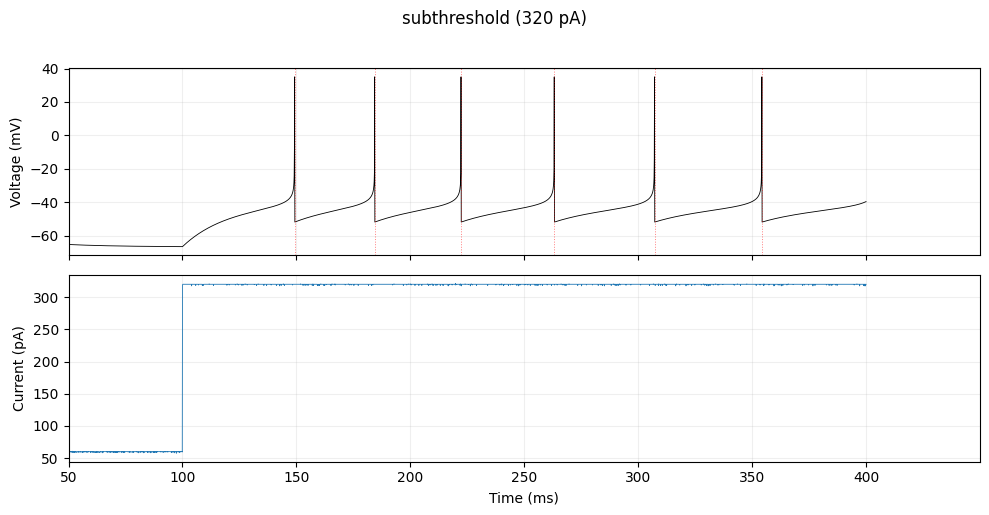

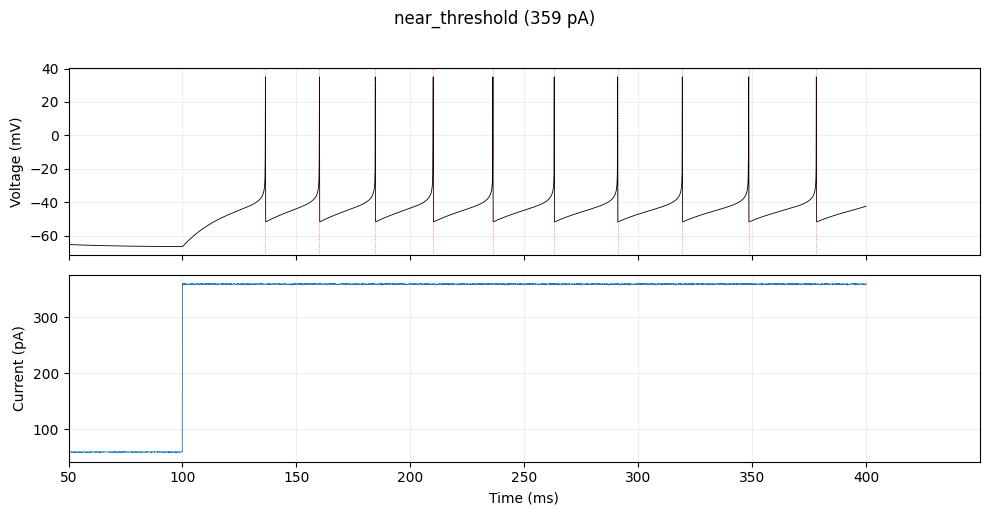

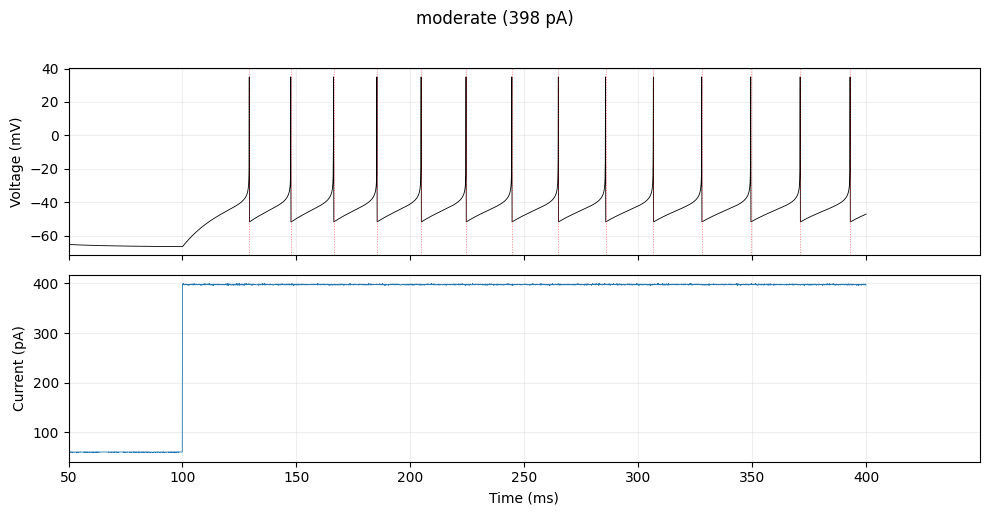

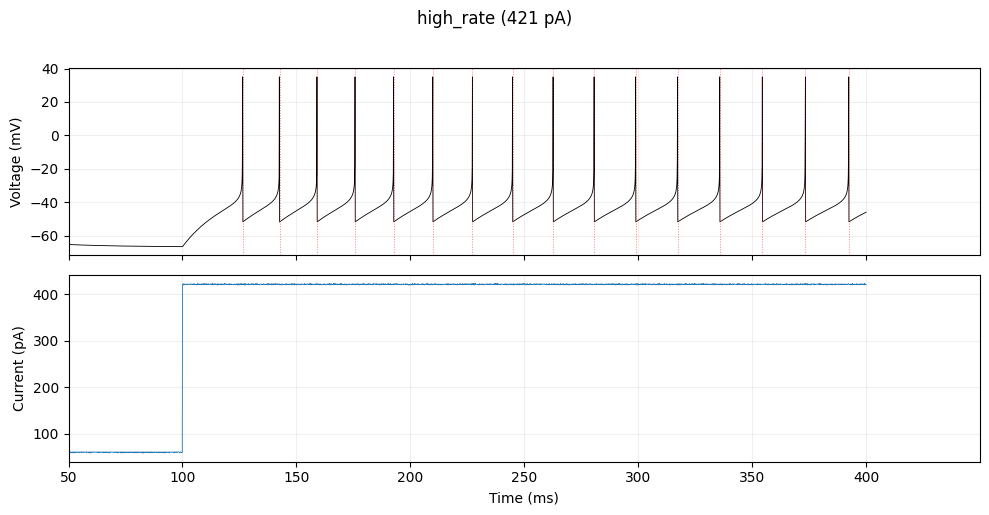

In [61]:
SPIKE_PEAK_MV = 35.0
SURROGATE_TYPE = "sigmoid"
SURROGATE_SLOPE = 5.0

target_data: dict[str, TraceData] = {}

for name, exp in exp_traces.items():
    sim = simulate_with_current_trace(
        params=ground_truth_params,
        current_trace_pA=exp.current,
        dt_ms=exp.dt_ms,
        use_surrogate=True,
        surrogate_type=SURROGATE_TYPE,
        surrogate_slope=SURROGATE_SLOPE,
    )

    n = len(exp.time)
    voltage_gt = sim.voltage[:n].copy()
    spike_times = sim.spike_times

    # Inject spike peaks (Jaxley resets within same timestep)
    for st in spike_times:
        idx = int(st / exp.dt_ms)
        if 0 <= idx < len(voltage_gt):
            voltage_gt[idx] = SPIKE_PEAK_MV

    target_data[name] = TraceData(
        time=exp.time,
        voltage=voltage_gt,
        current=exp.current,
        dt_ms=exp.dt_ms,
        spike_times=spike_times,
        stim_start_idx=exp.stim_start_idx,
        stim_end_idx=exp.stim_end_idx,
        stim_current_pA=exp.stim_current_pA,
    )

    print(f"  {name:<16} {sim.n_spikes} spikes, {sim.firing_rate_hz:.1f} Hz")

# Quick visual check
for name, td in target_data.items():
    trace_stim_window_plot(td)
    plt.gcf().suptitle(f"{name} ({td.stim_current_pA:.0f} pA)", y=1.02)
    plt.show()

## 4. Perturbed Initial Parameters

In [62]:
PERTURBATION = 0.15
TRAINABLE = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"]


def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


initial_params = perturb_params(
    ground_truth_params, TRAINABLE, PERTURBATION, jr.PRNGKey(SEED)
)

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in TRAINABLE:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
C_m               200.000      200.363     0.9%
g_L                10.000       10.273     6.8%
v_reset           -52.000      -51.247     5.0%
v_T               -45.000      -45.999     3.3%
E_L               -72.000      -71.488     7.3%
delta_T             3.000        2.537     2.6%


In [63]:
# Simulate initial fit for each trace
sims_init: dict[str, object] = {}
for name, td in target_data.items():
    sims_init[name] = simulate_with_current_trace(
        params=initial_params,
        current_trace_pA=td.current,
        dt_ms=td.dt_ms,
        use_surrogate=False,
    )
    print(f"  {name:<16} {sims_init[name].n_spikes} spikes (target: {td.n_spikes})")

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  subthreshold     8 spikes (target: 6)
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


  near_threshold   13 spikes (target: 10)
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


  moderate         17 spikes (target: 14)
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  high_rate        20 spikes (target: 16)


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


## 5. Multi-Trace Training — Guarino Loss

**Strategy** (idiomatic Jaxley pattern from `07_gradient_descent.ipynb`):
1. Create one cell via `setup_trainable_cell` with the first trace
2. Define `simulate(params, current_nA)` that calls `data_stimulate` + `jx.integrate`
3. `vmap` the simulation across all current traces (parallelized forward pass)
4. Compute per-trace Guarino loss, average across traces

In [ ]:
# --- Training config ---
training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.01,
    n_epochs=150,
    surrogate_type=SURROGATE_TYPE,
    surrogate_slope=SURROGATE_SLOPE,
    print_every=20,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

loss_config = GuarinoLossConfig()

# --- Create cell with first trace (just to get cell + trainable params) ---
first_trace = list(target_data.values())[0]
first_current_trace_nA = jnp.array(first_trace.current * initial_params["C_m"] / 1000.0)

cell, _, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=first_current_trace_nA,
    dt_ms=dt_ms,
    config=training_config,
    trainable_params=TRAINABLE,
)

# --- Stack all currents for vmap: shape (n_traces, T) ---
# NOTE: current is scaled by C_m (Jaxley expects nA = pA * C_m / 1000)
all_currents_nA = jnp.stack([
    jnp.array(td.current * initial_params["C_m"] / 1000.0)
    for td in target_data.values()
])
print(f"Stacked currents: {all_currents_nA.shape}")

# --- Extract experimental features for each trace ---
trace_names = list(target_data.keys())
exp_features_list: list[GuarinoFeatures] = []
for name in trace_names:
    td = target_data[name]
    feats = extract_experimental_features(
        voltage_trace=jnp.array(td.voltage),
        dt_ms=td.dt_ms,
        stim_duration_ms=td.stim_duration_ms,
        stim_end_index=td.stim_end_idx,
    )
    exp_features_list.append(feats)
    print(f"  {name:<16} n_spikes={float(feats.n_spikes):.0f}  "
          f"freq={float(feats.firing_frequency):.1f} Hz  "
          f"t_first={float(feats.t_first_spike):.1f} ms")

# --- Feature extractor (shared across traces — all have same dt, stim window) ---
feature_extractor = GuarinoFeatureExtractor(
    dt_ms=dt_ms,
    stim_duration_ms=first_trace.stim_duration_ms,
    stim_end_index=first_trace.stim_end_idx,
)

In [ ]:
# --- Define vmapped simulation (idiomatic Jaxley pattern) ---
def simulate(params, current_nA):
    """Simulate one trace. Vmapped over current_nA."""
    data_stimuli = cell.comp(0).data_stimulate(current_nA, None)
    return jx.integrate(
        cell, params=params, data_stimuli=data_stimuli,
        delta_t=dt_ms, t_max=t_max,
    )

batched_simulate = vmap(simulate, in_axes=(None, 0))


# --- Multi-trace loss function ---
def multi_trace_loss_fn(params):
    """Average Guarino loss across all traces."""
    # Batched forward pass: (n_traces, 3_recordings, T)
    all_results = batched_simulate(params, all_currents_nA)

    total_loss = 0.0
    for i in range(n_traces):
        voltage = all_results[i, 0, :]
        spikes = all_results[i, 2, :]

        # Truncate to stim window
        min_len = min(len(voltage), first_trace.stim_end_idx + 1)
        voltage = voltage[:min_len]
        spikes = spikes[:min_len]

        sim_features = feature_extractor.extract(voltage, spikes)
        total_loss = total_loss + guarino_loss(sim_features, exp_features_list[i], loss_config)

    return total_loss / n_traces


# Verify: initial multi-trace loss
initial_loss = float(multi_trace_loss_fn(trainable_params))
print(f"Initial multi-trace loss: {initial_loss:.4f}")

In [66]:
# --- Train ---
result = train(
    loss_fn=multi_trace_loss_fn,
    trainable_params=trainable_params,
    config=training_config,
    initial_params=initial_params,
)

print(f"\nTraining complete.")
print(f"  Best loss:   {result.best_loss:.4f} (epoch {result.best_epoch})")
print(f"  Final loss:  {result.final_loss:.4f}")
print(f"  Total time:  {result.total_time:.1f} s")

Training: optimizer=polyak lr=0.01 epochs=150 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=1.036354 | grad_norm=8.68e+02 | lr=1.04e-02 | C_m=200.3757, g_L=10.2755, v_reset=-51.2728, v_T=-45.7943, E_L=-71.4935, delta_T=2.5377
Epoch   20 | loss=0.239248 | grad_norm=7.56e+04 | lr=2.39e-03 | C_m=200.4546, g_L=10.2930, v_reset=-51.4038, v_T=-44.5296, E_L=-71.5325, delta_T=2.5413
Epoch   40 | loss=0.259809 | grad_norm=3.29e+02 | lr=2.60e-03 | C_m=200.4339, g_L=10.2954, v_reset=-51.4083, v_T=-44.4870, E_L=-71.5334, delta_T=2.5399
Epoch   60 | loss=0.286740 | grad_norm=4.22e+02 | lr=2.87e-03 | C_m=200.4262, g_L=10.2996, v_reset=-51.4047, v_T=-44.3553, E_L=-71.5410, delta_T=2.5389
Epoch   80 | loss=0.410299 | grad_norm=2.10e+00 | lr=4.10e-03 | C_m=200.4313, g_L=10.2990, v_reset=-51.3909, v_T=-44.3122, E_L=-71.5408, delta_T=2.5394
Epoch  100 | loss=0.281109 | grad_norm=1.54e-01 | lr=2.81e-03 | C_m=200.4187, g_L=10.2982, v_reset=-51.3828, v_T=-44.3872, E_L=-


Training complete.
  Best loss:   0.2293 (epoch 15)
  Final loss:  0.4307
  Total time:  138.0 s


## 6. Evaluation — Per-Trace Results

Simulate each trace with the trained parameters and compute coincidence factor.

In [67]:
# Build final parameter dict
trained_dict = result.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_dict)

# --- Simulate and evaluate each trace ---
sims_final: dict[str, object] = {}
gammas: dict[str, float | None] = {}

for name, td in target_data.items():
    sim = simulate_with_current_trace(
        params=params_final,
        current_trace_pA=td.current,
        dt_ms=td.dt_ms,
        use_surrogate=True,
    )
    sims_final[name] = sim

    if sim.n_spikes > 0 and td.n_spikes > 0:
        cf = coincidence_factor(
            spike_times_data=td.spike_times,
            spike_times_model=sim.spike_times,
            duration_ms=td.stim_duration_ms,
            delta_ms=4,
        )
        gammas[name] = cf.gamma
    else:
        cf = None
        gammas[name] = None

    gamma_str = f"{cf.gamma:.3f}" if cf else "N/A"
    print(f"  {name:<16} spikes: {sim.n_spikes:>2} (target {td.n_spikes:>2})  Gamma: {gamma_str}")

# Mean Gamma (only over traces where both have spikes)
valid_gammas = [g for g in gammas.values() if g is not None]
if valid_gammas:
    print(f"\n  Mean Gamma (spiking traces): {np.mean(valid_gammas):.3f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  subthreshold     spikes:  6 (target  6)  Gamma: 0.206
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  near_threshold   spikes: 10 (target 10)  Gamma: 1.000
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  moderate         spikes: 14 (target 14)  Gamma: 0.202
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
  high_rate        spikes: 16 (target 16)  Gamma: 0.019

  Mean Gamma (spiking traces): 0.357


## 7. Parameter Recovery

In [68]:
print("Parameter Recovery: Ground Truth vs Trained")
print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Final':>12} {'Error (%)':>10}")
print("-" * 62)
for k in TRAINABLE:
    gt = ground_truth_params[k]
    init = initial_params[k]
    final = params_final.get(k, init)
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(final - gt) / (bounds.max - bounds.min) * 100
    init_err = abs(init - gt) / (bounds.max - bounds.min) * 100
    arrow = "<-" if err_pct < init_err else "->"
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {final:>12.3f} {err_pct:>9.1f}% {arrow}")

Parameter Recovery: Ground Truth vs Trained
Parameter    Ground Truth      Initial        Final  Error (%)
--------------------------------------------------------------
C_m               200.000      200.363      200.446       1.1% ->
g_L                10.000       10.273       10.290       7.3% ->
v_reset           -52.000      -51.247      -51.389       4.1% <-
v_T               -45.000      -45.999      -44.698       1.0% <-
E_L               -72.000      -71.488      -71.527       6.8% <-
delta_T             3.000        2.537        2.541       2.6% <-


## 8. Plots

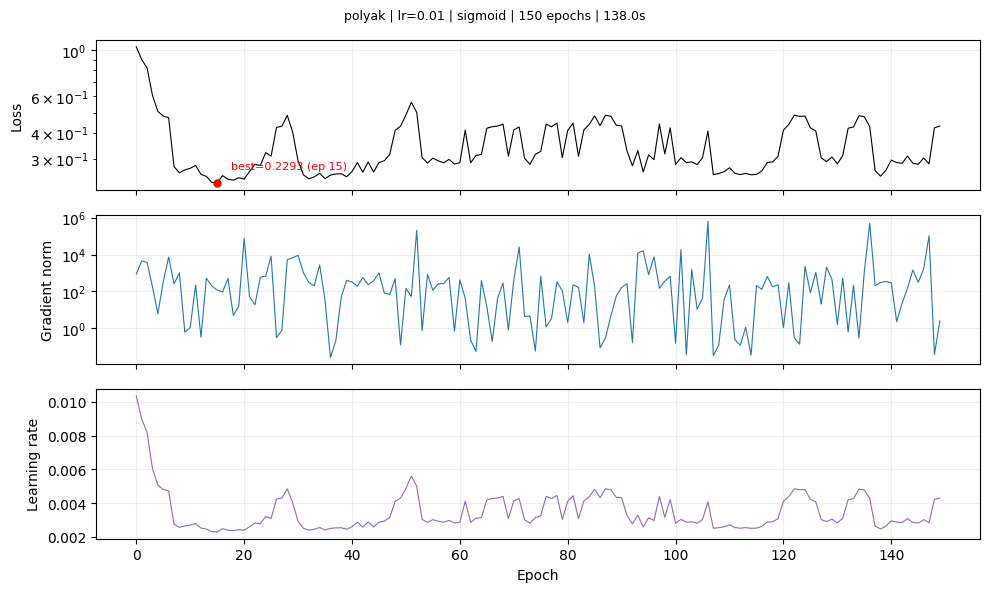

In [69]:
# Training history
training_history_plot(result);

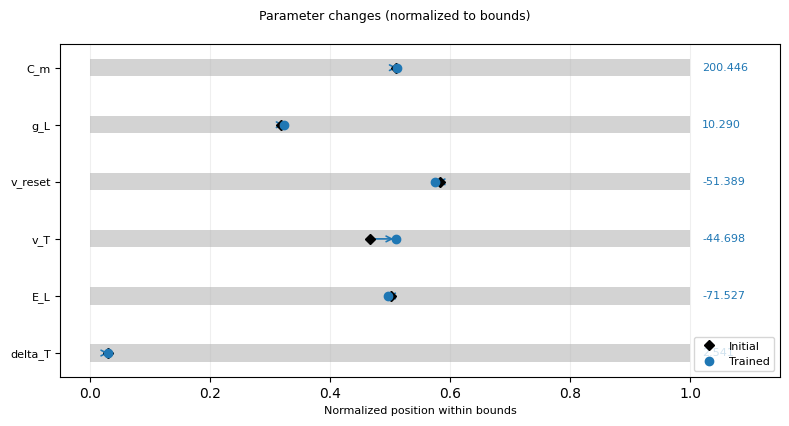

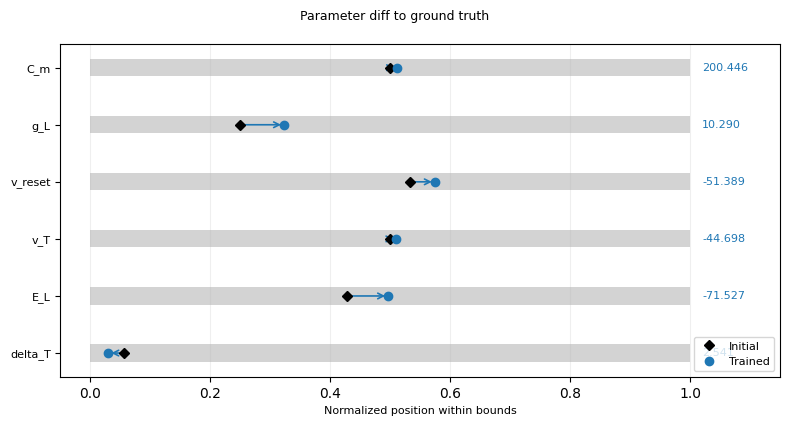

In [70]:
# Parameter comparison (trained vs initial)
parameter_comparison_plot(result);

# Parameter comparison (trained vs ground truth)
parameter_comparison_plot(
    TrainingResult(
        trainable_params=result.trainable_params,
        loss_history=result.loss_history,
        time_per_epoch=result.time_per_epoch,
        config=result.config,
        initial_params=ground_truth_params,
    ),
    figtitle="Parameter diff to ground truth",
);

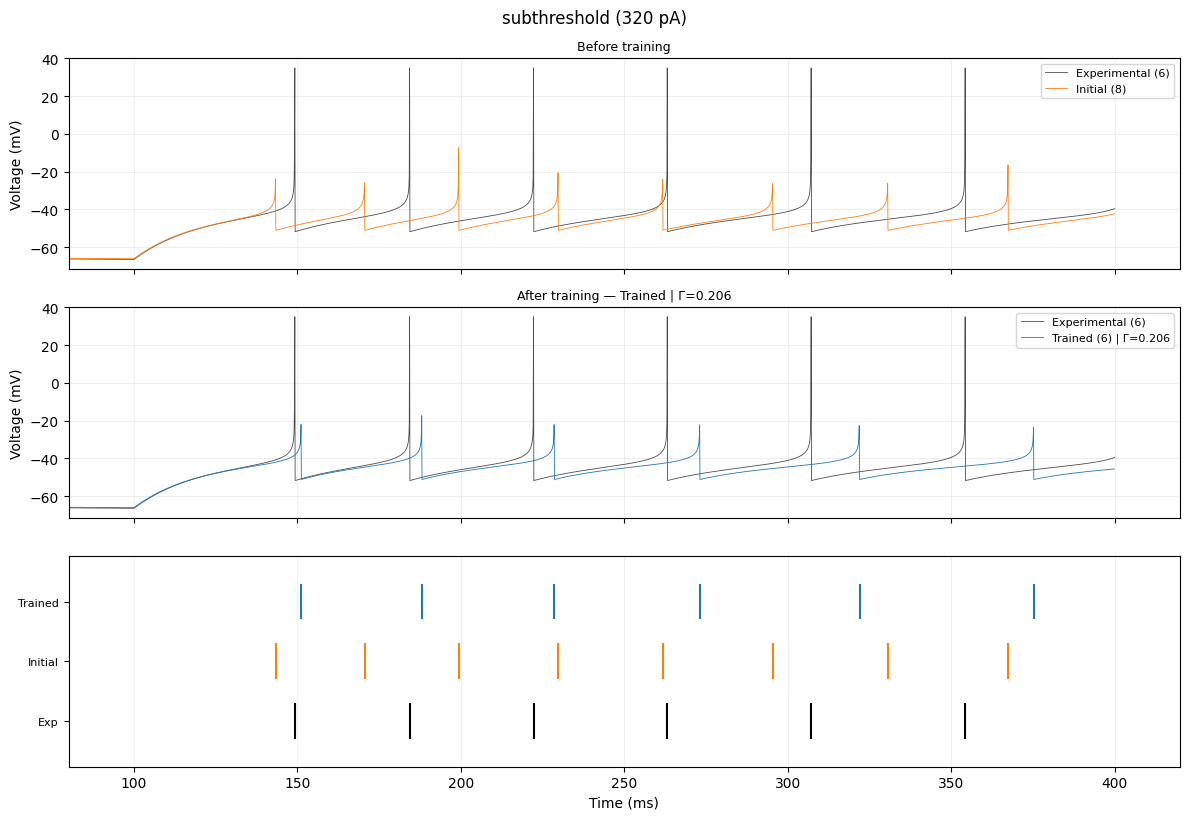

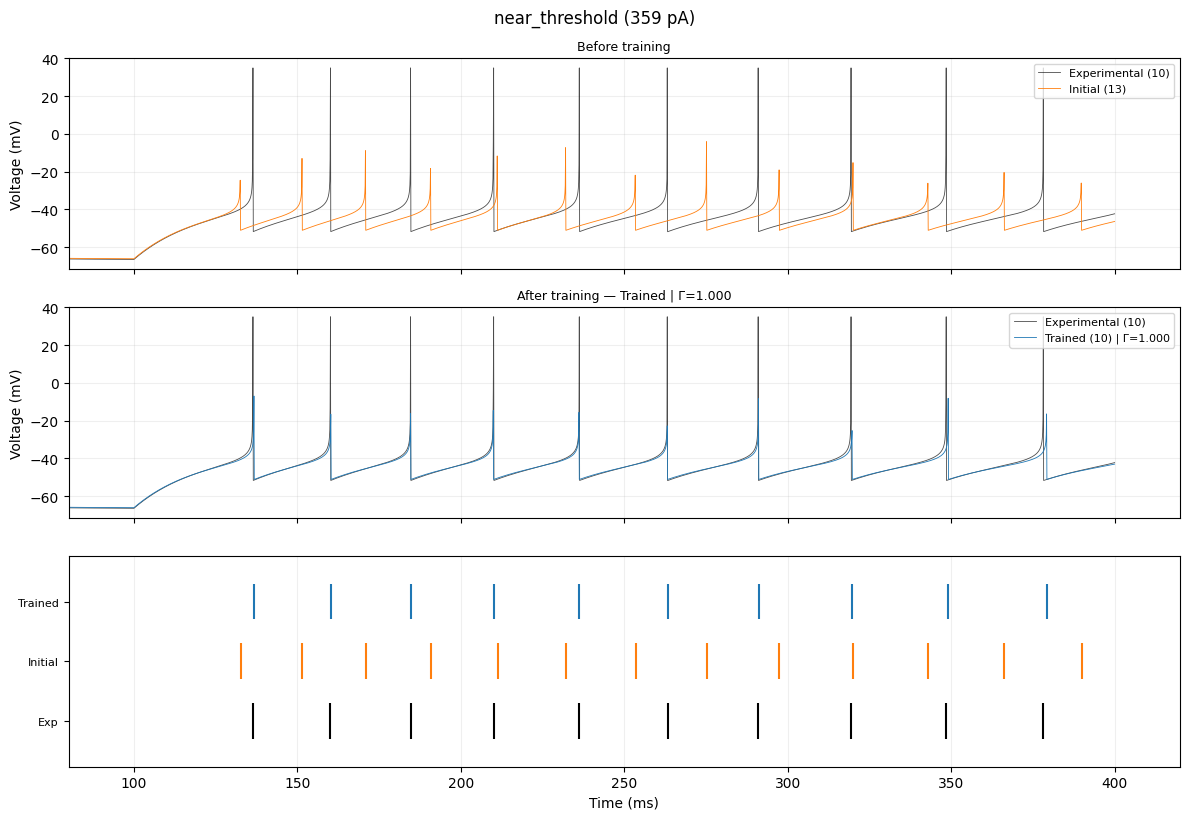

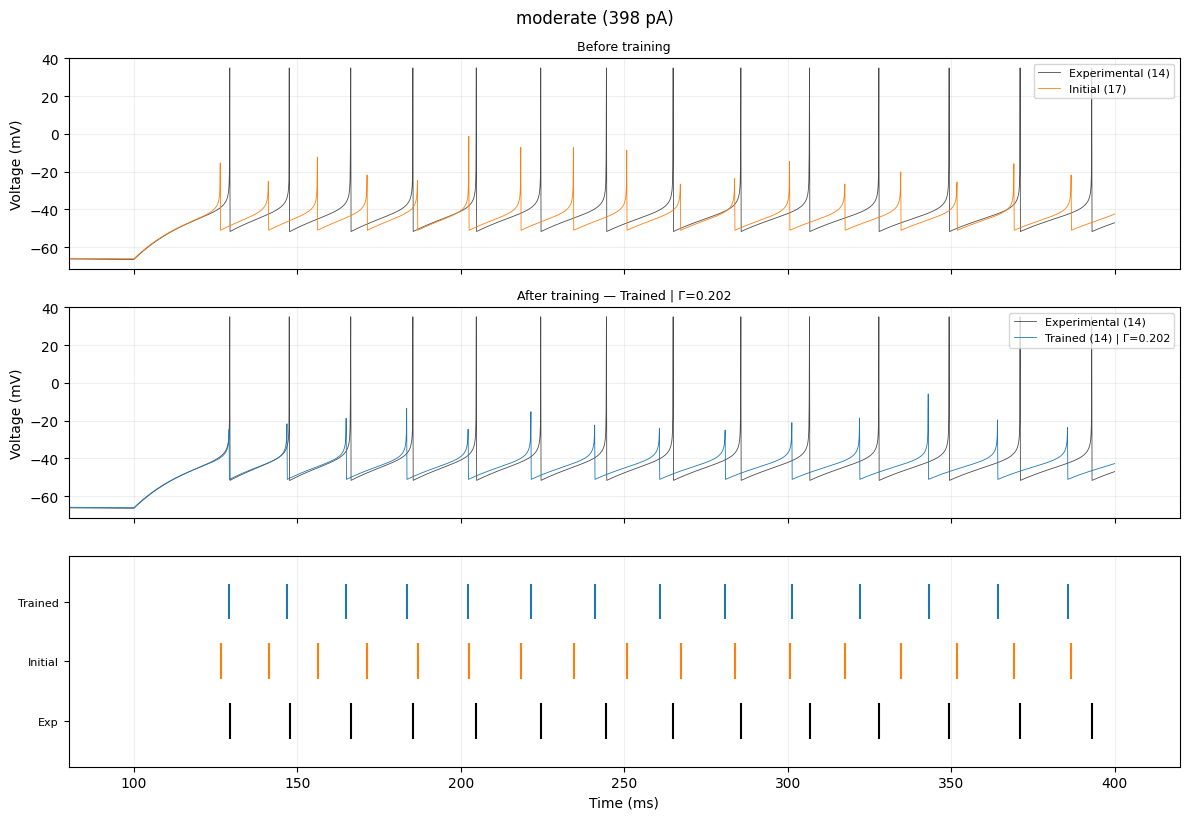

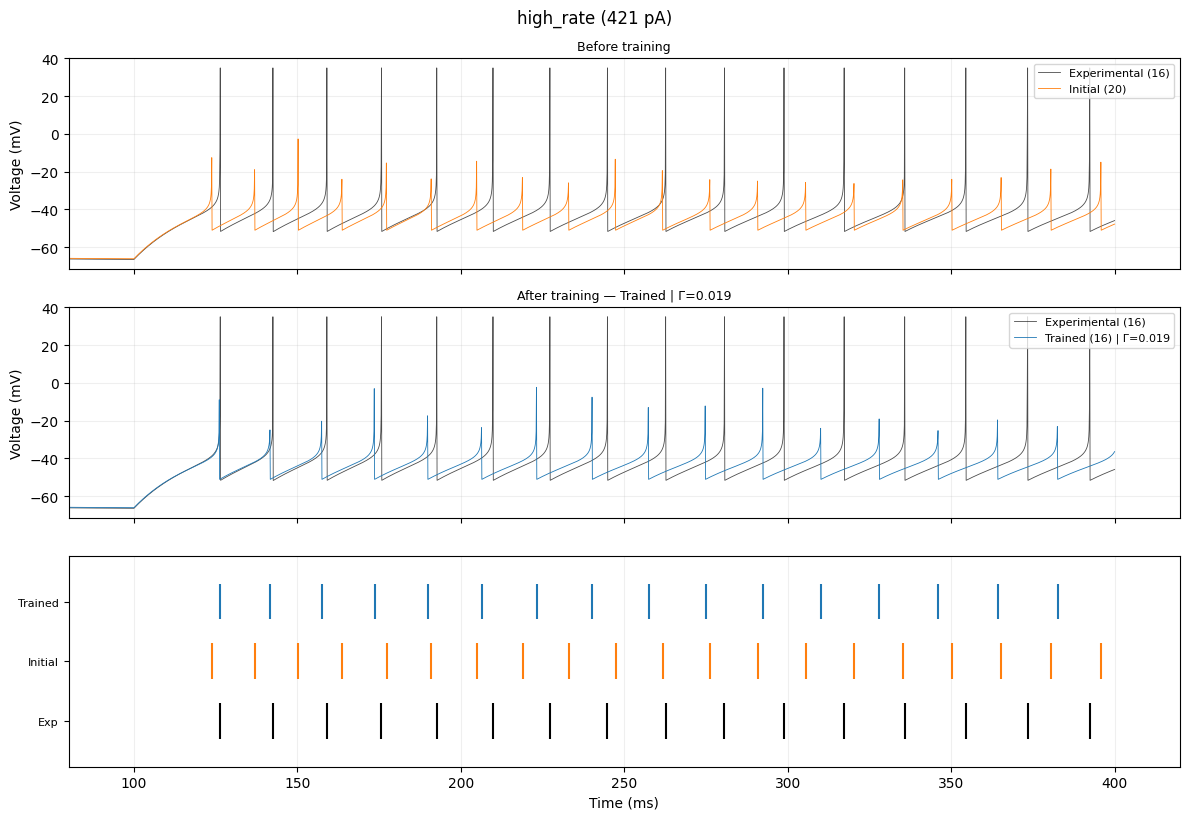

In [71]:
# Per-trace fit comparison: before/after for each trace
for name in trace_names:
    td = target_data[name]
    sim_i = sims_init[name]
    sim_f = sims_final[name]

    # Compute coincidence for initial and final
    cfs = []
    for sim in [sim_f]:
        if sim.n_spikes > 0 and td.n_spikes > 0:
            cfs.append(coincidence_factor(
                spike_times_data=td.spike_times,
                spike_times_model=sim.spike_times,
                duration_ms=td.stim_duration_ms,
                delta_ms=4,
            ))
        else:
            cfs.append(None)

    fit_before_after_plot(
        td, sim_i, [sim_f],
        coincidence=cfs,
        labels=["Trained"],
    )
    plt.gcf().suptitle(f"{name} ({td.stim_current_pA:.0f} pA)", y=1.02)
    plt.show()